# Analyse results from Pypsa-Earth

Is not working with the 12 cluster voronoi approach! And generally probably not working with sector-coupled results.. further investugation needed, but no top priority

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Own setting

In [1]:
import os
import sys
import yaml

PARENT = os.path.realpath("../../pypsa-earth") + "/"
# config = yaml.safe_load(open(PARENT + "config-2030-NetZero-3TWh-Hydro.yaml"))
config = yaml.safe_load(open(PARENT + "config-2030_DZ-voroni-sec-12-24H.yaml"))

# Read config.yaml settings:
name = config["run"]["name"]
simpl = config["scenario"]["simpl"]
# clusters = "10"
clusters = config["scenario"]["clusters"]
ll = config["scenario"]["ll"]
opts = config["scenario"]["opts"]

# Ensure elements are strings and properly joined
simpl_str = "_".join(map(str, simpl))
clusters_str = "_".join(map(str, clusters))
#clusters_str = clusters
ll_str = "_".join(map(str, ll))
opts_str = "_".join(map(str, opts))
export = "1"
geothermal_potential = "3"

## Import packages

In [2]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy

## Path settings

In [5]:
# nc_file_name = f"elec_s{simpl_str}_{clusters_str}_ec_l{ll_str}_{opts_str}-{export}-{geothermal_potential}.nc"
nc_file_name = f"elec_s{simpl_str}_{clusters_str}_ec_l{ll_str}_{opts_str}.nc"
scenario_name = name 
scenario_subpath = scenario_name + "/" if scenario_name else ""

# Network file
#results_path = PARENT + f"results/{scenario_subpath}networks/{nc_file_name}"
results_path = PARENT + f"results/DZA-1/postnetworks/elec_s_12_ec_lcopt_Co2L-24H_24H_2030_0.071_AB_10export.nc"
#network_path = PARENT + f"networks/{scenario_subpath}elec.nc"
# Country shape file
regions_onshore_path = PARENT + f"resources/{scenario_subpath}shapes/country_shapes.geojson"
# Renewable profile file
solar_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_solar.nc"
onwind_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_onwind.nc"

## Energy system analysis setup - power and energy generation

In [22]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

Index(['H2 pipeline not found 0_AC -> not found 0_AC repurposed',
       'H2 pipeline not found 0_AC -> not found 1_AC repurposed',
       'H2 pipeline not found 0_AC -> not found 3_AC repurposed',
       'H2 pipeline not found 0_AC -> not found 5_AC repurposed',
       'H2 pipeline not found 0_AC -> not found 6_AC repurposed',
       'H2 pipeline not found 0_AC -> not found 9_AC repurposed',
       'H2 pipeline not found 10_AC -> not found 2_AC repurposed',
       'H2 pipeline not found 11_AC -> not found 3_AC repurposed',
       'H2 pipeline not found 1_AC -> not found 11_AC repurposed',
       'H2 pipeline not found 1_AC -> not found 7_AC repurposed',
       'H2 pipeline not found 1_AC -> not found 9_AC repurposed',
       'H2 pipeline not found 2_AC -> not found 4_AC repurposed',
       'H2 pipeline not found 2_AC -> not found 5_AC repurposed',
       'H2 pipeline not found 2_AC -> not found 7_AC repurposed',
       'H2 pipeline not found 3_AC -> not found 5_AC repurposed',
       

In [28]:
n.links[n.links['carrier'] == 'transmission']

,bus0,bus1,carrier,p_nom_extendable,efficiency,capital_cost,bus2,bus3,bus4,efficiency2,...,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Link,,,,,,,,,,,,,,,,,,,,,


In [29]:
n.links

,bus0,bus1,carrier,p_nom_extendable,efficiency,capital_cost,bus2,bus3,bus4,efficiency2,...,start_up_cost,shut_down_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Link,,,,,,,,,,,,,,,,,,,,,
DZ0 0 co2 vent,DZ0 0 co2 stored,co2 atmosphere,co2 vent,True,1.0,0.00000,,,,1.00,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ0 1 co2 vent,DZ0 1 co2 stored,co2 atmosphere,co2 vent,True,1.0,0.00000,,,,1.00,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ0 10 co2 vent,DZ0 10 co2 stored,co2 atmosphere,co2 vent,True,1.0,0.00000,,,,1.00,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ0 11 co2 vent,DZ0 11 co2 stored,co2 atmosphere,co2 vent,True,1.0,0.00000,,,,1.00,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ0 2 co2 vent,DZ0 2 co2 stored,co2 atmosphere,co2 vent,True,1.0,0.00000,,,,1.00,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
DZ7 1 urban central DAC,co2 atmosphere,DZ7 1 co2 stored,DAC,True,1.0,863357.55446,DZ7 1,DZ7 1 urban central heat,,-0.55,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ8 0 urban central DAC,co2 atmosphere,DZ8 0 co2 stored,DAC,True,1.0,863357.55446,DZ8 0,DZ8 0 urban central heat,,-0.55,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
DZ9 0 urban central DAC,co2 atmosphere,DZ9 0 co2 stored,DAC,True,1.0,863357.55446,DZ9 0,DZ9 0 urban central heat,,-0.55,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0


In [19]:
n.buses.x.mean()

-598.1777965659911

## Data import check

Country check

In [21]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

GEOSException: IllegalArgumentException: Points of LinearRing do not form a closed linestring

Component check

In [11]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 868 entries
Component 'Carrier' has 38 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 31 entries
Component 'LineType' has 34 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 2226 entries
Component 'Load' has 1091 entries
Component 'Generator' has 1326 entries
Component 'StorageUnit' has 1 entries
Component 'Store' has 579 entries


In [12]:
buses = n.buses.loc[n.buses['carrier']=='AC']
buses_geo = gpd.points_from_xy(buses["lon"], buses["lat"])
buses_gdf = gpd.GeoDataFrame(buses, geometry=buses_geo, crs=4326)


In [13]:
buses_gdf.explore()

Snapshot check

In [14]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2013-12-22', '2013-12-23', '2013-12-24', '2013-12-25',
               '2013-12-26', '2013-12-27', '2013-12-28', '2013-12-29',
               '2013-12-30', '2013-12-31'],
              dtype='datetime64[ns]', name='snapshot', length=365, freq=None)
Time steps: 365


## Analyse energy system

Analyse the current capacity of the energy system - map view

In [15]:
# Scale settings
bus_scale = 3e3 
line_scale = 2e3

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100, 1000]  # in MW

# n-noLoad = n.carriers.drop("Load", inplace=False)
n.carriers.drop("Load", inplace=True)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.1,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])

# Make more space at bottom to not cut off capacity circle
ylims = ax.get_ylim()  # Get current y-axis limits
ax.set_ylim(ylims[0] - 1e5, ylims[1] + 1e5)  # Extend the bottom and top by shifting downward + upward

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()
fig.savefig("brownfield_capacities_" + scenario_name + ".png", bbox_inches="tight", dpi=300)

GEOSException: IllegalArgumentException: Points of LinearRing do not form a closed linestring

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier')

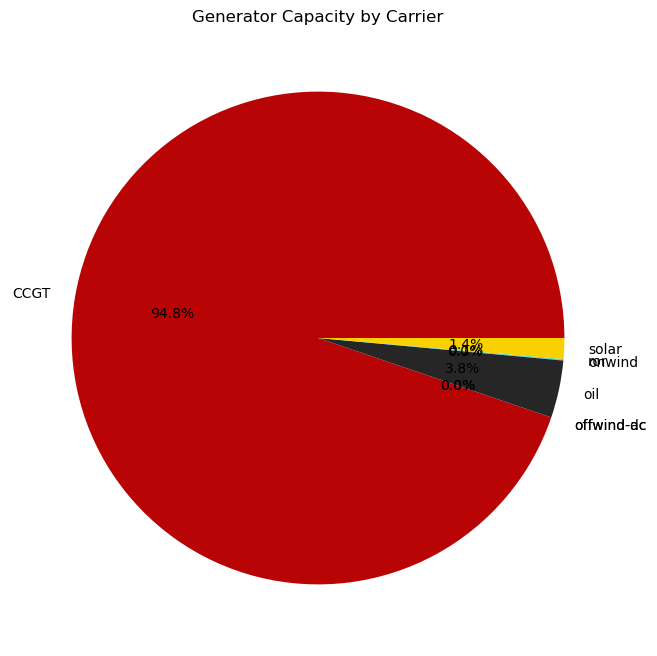

In [ ]:
generator_capacity_by_carrier = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["carrier"]).p_nom.sum()
plt.figure(figsize=(8, 8))
plt.pie(generator_capacity_by_carrier, labels=generator_capacity_by_carrier.index, autopct='%1.1f%%', colors=n.carriers[n.carriers.index.isin(generator_capacity_by_carrier.index)].color.reindex(generator_capacity_by_carrier.index))
plt.title("Generator Capacity by Carrier")

Analyse the current gernation capacity of the energy system - tabular view

In [ ]:
generator_capacity_by_carrier/1e3 # in GW

carrier
CCGT          29.635056
offwind-ac     0.000000
offwind-dc     0.000000
oil            1.176446
onwind         0.009506
ror            0.021378
solar          0.425800
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

In [16]:
bus_scale = 3e3 
line_scale = 2e3

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])

# Make more space at bottom to not cut off capacity circle
ylims = ax.get_ylim()  # Get current y-axis limits
ax.set_ylim(ylims[0] - 0.7e5, ylims[1] + 0.7e5)  # Extend the bottom by shifting downward

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

GEOSException: IllegalArgumentException: Points of LinearRing do not form a closed linestring

Calculate emissions of future energy system

In [ ]:
#ToDo: Not fully correct - double check
co2_emissions = pd.DataFrame(data=n.carriers[["co2_emissions", "nice_name"]]).set_index("nice_name").squeeze().rename_axis("carrier")

energy_production = n.statistics.energy_balance().Generator.droplevel(1).drop(["load", "export"], errors="ignore")

co2_emissions_technology = energy_production * co2_emissions.loc[energy_production.index] * n.snapshot_weightings.generators[0]
co2_emissions_technology

/tmp/ipykernel_1475/272665663.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2_emissions_technology = energy_production * co2_emissions.loc[energy_production.index] * n.snapshot_weightings.generators[0]


carrier
Offshore Wind (AC)    0.0
Onshore Wind          0.0
Run of River          0.0
Solar                 0.0
dtype: float64

In [ ]:
co2_emissions_sum = co2_emissions_technology.sum()
co2_emissions_sum

0.0

In [ ]:
n.global_constraints

,sense,mu,type,investment_period,carrier_attribute,constant
GlobalConstraint,,,,,,
CO2Limit,<=,-10514.356146,primary_energy,NaN,co2_emissions,0.0


In [ ]:
# Step 1: Create the links_energy DataFrame with "carrier" and "bus0" columns
links_energy = n.links[["carrier", "bus0"]]

# Step 2: Filter only rows where "carrier" contains 'export'
links_energy = links_energy[links_energy["carrier"].str.contains("export", case=False, na=False)]

# Step 3: Calculate the energy sum for indices that contain 'export'
export_energy = n.links_t.p0.sum()
export_energy = export_energy[export_energy.index.str.contains("export", case=False, na=False)]

# Step 4: Map the energy sum to the correct rows in links_energy based on the index
links_energy["energy"] = links_energy.index.map(export_energy)

# Step 5: Group by "bus0" and "carrier" and sum the "energy" values
links_energy_grouped = links_energy.groupby(["bus0", "carrier"], as_index=False)["energy"].sum()

# Display the result
links_energy_grouped


,bus0,carrier,energy


Analys the future generation capacity expansion of the energy system - bar chart

In [ ]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion

carrier
Combined-Cycle Gas     0.000000
Offshore Wind (AC)          NaN
Oil                    0.000000
Onshore Wind           1.807775
Run of River           0.000000
Solar                 71.238540
load                   0.000000
dtype: float64

Plot the future generation capacity expansion of the energy system - tabular chart

<AxesSubplot:title={'center':'Generator capacity expansion in GW'}, xlabel='carrier'>

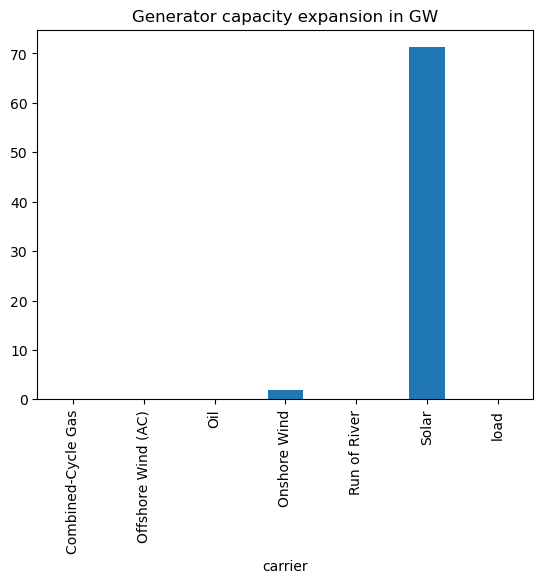

In [ ]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Analyse the future energy generation of the energy system - bar chart view

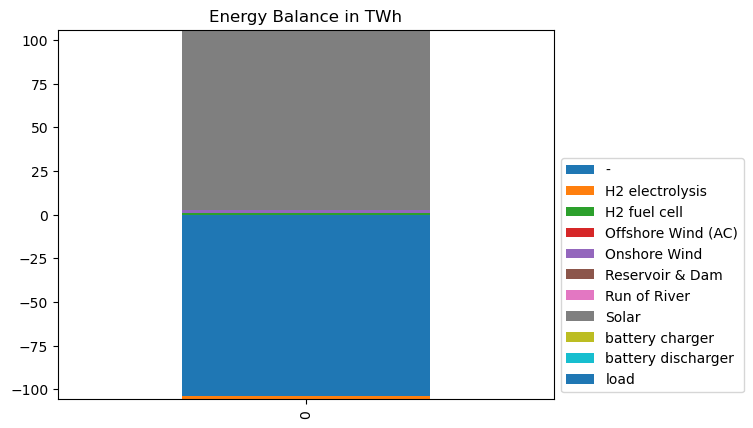

In [ ]:
fig, ax = plt.subplots()
color_setting = n.carriers.set_index(n.carriers.nice_name)
energy_balance = n.statistics.energy_balance().loc[:, :, "AC"].groupby("carrier").sum().div(1e6).to_frame().T
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh")
n.carriers[n.carriers.index.isin(generator_capacity_by_carrier.index)].color.reindex(generator_capacity_by_carrier.index)

ax.legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

In [ ]:
n.statistics.energy_balance()

component    carrier             bus_carrier
Load         -                   AC            -1.040156e+08
Link         H2 electrolysis     AC            -1.838293e+06
             H2 fuel cell        H2            -1.470634e+06
             battery charger     AC            -5.213015e+02
             battery discharger  battery       -4.691805e+02
             H2 electrolysis     H2             1.470634e+06
             H2 fuel cell        AC             8.529678e+05
             battery charger     battery        4.691713e+02
             battery discharger  AC             4.222624e+02
Store        Battery Storage     battery       -6.921547e-16
             Hydrogen Storage    H2            -3.704477e-10
StorageUnit  Reservoir & Dam     AC             1.221527e+05
Generator    Offshore Wind (AC)  AC             3.020358e-02
             Onshore Wind        AC             1.648067e+06
             Run of River        AC             1.867523e+05
             Solar               AC     

Analyse the future energy generation of the energy system - tabular view

In [ ]:
n.statistics.energy_balance()/1e6 # In TWh

component    carrier             bus_carrier
Load         -                   AC            -1.040156e+02
Link         H2 electrolysis     AC            -1.838293e+00
             H2 fuel cell        H2            -1.470634e+00
             battery charger     AC            -5.213015e-04
             battery discharger  battery       -4.691805e-04
             H2 electrolysis     H2             1.470634e+00
             H2 fuel cell        AC             8.529678e-01
             battery charger     battery        4.691713e-04
             battery discharger  AC             4.222624e-04
Store        Battery Storage     battery       -6.921547e-22
             Hydrogen Storage    H2            -3.704477e-16
StorageUnit  Reservoir & Dam     AC             1.221527e-01
Generator    Offshore Wind (AC)  AC             3.020358e-08
             Onshore Wind        AC             1.648067e+00
             Run of River        AC             1.867523e-01
             Solar               AC     

## Analyse pv and wind potential - map view

In [ ]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    # br = gpd.read_file(f"resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br = gpd.read_file(PARENT + f"resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot pv energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


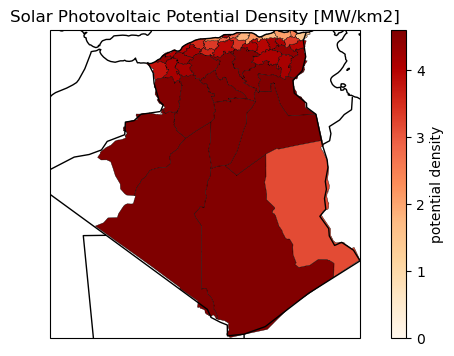

In [ ]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot wind energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


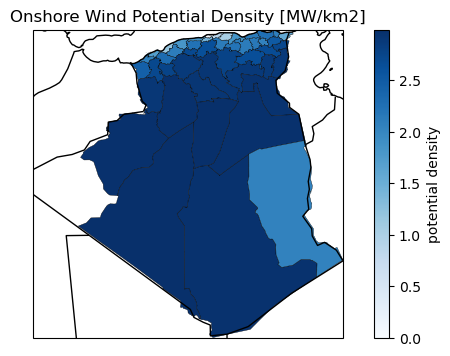

In [ ]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Levelized cost of electricity

In [ ]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity generation
# n.statistics.market_value() ?
lcoe = n.objective/n.statistics.energy_balance().Generator.sum()
lcoe 

41.382233286645906

In [ ]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity demand
lcoe = n.objective/n.statistics.energy_balance().Load.sum()*(-1)
lcoe 

41.7256825750005

In [ ]:
n.statistics.market_value()

component    carrier           
Generator    Offshore Wind (AC)     60.980792
             Onshore Wind          120.500485
             Run of River           47.886958
             Solar                  35.381612
             load                   43.886462
Line         AC                      1.126230
Link         H2 electrolysis        57.363948
             H2 fuel cell          104.777094
             battery charger         0.753175
             battery discharger     -0.944670
Load         -                            NaN
StorageUnit  Reservoir & Dam       336.010849
Store        Battery Storage       185.986626
             Hydrogen Storage       50.465329
dtype: float64

Check storages

In [ ]:
n.storage_units

,carrier,bus,p_nom,max_hours,p_min_pu,efficiency_dispatch,efficiency_store,cyclic_state_of_charge,control,marginal_cost,...,marginal_cost_quadratic,capital_cost,build_year,lifetime,state_of_charge_initial,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge_per_period,standing_loss,inflow
StorageUnit,,,,,,,,,,,,,,,,,,,,,
DZ.8_1_AC hydro,hydro,DZ.8_1_AC,100.0,2710.628395,0.0,0.9,0.0,True,,0.00992,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0


## Additional input (Marco)

In [ ]:
CCGT_col = [col for col in n.generators_t.p.columns if 'CCGT' in col]
n.generators_t.p[CCGT_col].sum()

Generator
DZ.10_1_AC CCGT    0.0
DZ.13_1_AC CCGT    0.0
DZ.16_1_AC CCGT    0.0
DZ.19_1_AC CCGT    0.0
DZ.23_1_AC CCGT    0.0
DZ.24_1_AC CCGT    0.0
DZ.25_1_AC CCGT    0.0
DZ.26_1_AC CCGT    0.0
DZ.28_1_AC CCGT    0.0
DZ.30_1_AC CCGT    0.0
DZ.31_1_AC CCGT    0.0
DZ.32_1_AC CCGT    0.0
DZ.33_1_AC CCGT    0.0
DZ.34_1_AC CCGT    0.0
DZ.35_1_AC CCGT    0.0
DZ.37_1_AC CCGT    0.0
DZ.39_1_AC CCGT    0.0
DZ.3_1_AC CCGT     0.0
DZ.41_1_AC CCGT    0.0
DZ.43_1_AC CCGT    0.0
DZ.45_1_AC CCGT    0.0
DZ.4_1_AC CCGT     0.0
DZ.5_1_AC CCGT     0.0
DZ.6_1_AC CCGT     0.0
DZ.9_1_AC CCGT     0.0
dtype: float64

In [ ]:
n.generators_t.p.columns

Index(['DZ.10_1_AC CCGT', 'DZ.10_1_AC H2 load', 'DZ.10_1_AC battery load',
       'DZ.10_1_AC load', 'DZ.10_1_AC onwind', 'DZ.10_1_AC solar',
       'DZ.11_1_AC H2 load', 'DZ.11_1_AC battery load', 'DZ.11_1_AC load',
       'DZ.11_1_AC onwind',
       ...
       'DZ.8_1_AC load', 'DZ.8_1_AC onwind', 'DZ.8_1_AC ror',
       'DZ.8_1_AC solar', 'DZ.9_1_AC CCGT', 'DZ.9_1_AC H2 load',
       'DZ.9_1_AC battery load', 'DZ.9_1_AC load', 'DZ.9_1_AC onwind',
       'DZ.9_1_AC solar'],
      dtype='object', name='Generator', length=268)

In [ ]:
n.generators_t.p

Generator,DZ.10_1_AC CCGT,DZ.10_1_AC H2 load,DZ.10_1_AC battery load,DZ.10_1_AC load,DZ.10_1_AC onwind,DZ.10_1_AC solar,DZ.11_1_AC H2 load,DZ.11_1_AC battery load,DZ.11_1_AC load,DZ.11_1_AC onwind,...,DZ.8_1_AC load,DZ.8_1_AC onwind,DZ.8_1_AC ror,DZ.8_1_AC solar,DZ.9_1_AC CCGT,DZ.9_1_AC H2 load,DZ.9_1_AC battery load,DZ.9_1_AC load,DZ.9_1_AC onwind,DZ.9_1_AC solar
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,0.0,0.000032,0.000032,0.000032,0.000028,0.014914,0.000032,0.000032,0.000032,0.000022,...,0.000032,0.000036,21.377912,0.029438,0.0,0.000032,0.000032,0.000032,0.000049,0.488568
2013-01-01 12:00:00,0.0,0.000032,0.000032,0.000032,0.000024,0.017840,0.000032,0.000032,0.000032,0.000014,...,0.000032,0.000024,21.377913,0.046479,0.0,0.000032,0.000032,0.000032,0.000054,0.801319
2013-01-02 00:00:00,0.0,0.000032,0.000032,0.000032,0.000008,0.010721,0.000032,0.000032,0.000032,0.000000,...,0.000032,0.000045,21.377912,0.013519,0.0,0.000032,0.000032,0.000032,0.000010,0.317637
2013-01-02 12:00:00,0.0,0.000032,0.000032,0.000032,0.000010,0.018627,0.000032,0.000032,0.000032,0.000010,...,0.000032,0.000016,21.377912,0.027598,0.0,0.000032,0.000032,0.000032,0.000000,0.595484
2013-01-03 00:00:00,0.0,0.000032,0.000032,0.000032,0.000006,0.008387,0.000032,0.000032,0.000032,0.000015,...,0.000032,0.000000,21.377912,0.020397,0.0,0.000032,0.000032,0.000032,0.000221,0.248568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-29 12:00:00,0.0,0.000032,0.000032,0.000032,0.000027,0.005141,0.000032,0.000032,0.000032,0.000036,...,0.000032,0.000021,21.377909,0.005501,0.0,0.000032,0.000032,0.000032,0.000373,0.295076
2013-12-30 00:00:00,0.0,0.000032,0.000032,0.000032,0.000016,0.011802,0.000032,0.000032,0.000032,0.000020,...,0.000032,0.000000,21.377908,0.014742,0.0,0.000032,0.000032,0.000032,0.000734,0.054082
2013-12-30 12:00:00,0.0,0.000032,0.000032,0.000032,0.000006,0.006764,0.000032,0.000031,0.000032,0.000013,...,0.000032,0.000008,21.260472,0.013878,0.0,0.000032,0.000032,0.000032,0.000170,0.065000


In [ ]:
import re

df = n.generators_t.p

# Extract the category (everything after "GH0 <number> ")
categories = [re.sub(r'GH0 \d+ ', '', col) for col in df.columns]

# Create a mapping from the original column names to their categories
column_mapping = dict(zip(df.columns, categories))

# Group by category
grouped = {}
for col, category in column_mapping.items():
    grouped.setdefault(category, []).append(col)

# Print grouped columns
for category, cols in grouped.items():
    print(f"{category}: {cols}")

print(grouped)

DZ.10_1_AC CCGT: ['DZ.10_1_AC CCGT']
DZ.10_1_AC H2 load: ['DZ.10_1_AC H2 load']
DZ.10_1_AC battery load: ['DZ.10_1_AC battery load']
DZ.10_1_AC load: ['DZ.10_1_AC load']
DZ.10_1_AC onwind: ['DZ.10_1_AC onwind']
DZ.10_1_AC solar: ['DZ.10_1_AC solar']
DZ.11_1_AC H2 load: ['DZ.11_1_AC H2 load']
DZ.11_1_AC battery load: ['DZ.11_1_AC battery load']
DZ.11_1_AC load: ['DZ.11_1_AC load']
DZ.11_1_AC onwind: ['DZ.11_1_AC onwind']
DZ.11_1_AC solar: ['DZ.11_1_AC solar']
DZ.12_1_AC H2 load: ['DZ.12_1_AC H2 load']
DZ.12_1_AC battery load: ['DZ.12_1_AC battery load']
DZ.12_1_AC load: ['DZ.12_1_AC load']
DZ.12_1_AC onwind: ['DZ.12_1_AC onwind']
DZ.12_1_AC solar: ['DZ.12_1_AC solar']
DZ.13_1_AC CCGT: ['DZ.13_1_AC CCGT']
DZ.13_1_AC H2 load: ['DZ.13_1_AC H2 load']
DZ.13_1_AC battery load: ['DZ.13_1_AC battery load']
DZ.13_1_AC load: ['DZ.13_1_AC load']
DZ.13_1_AC onwind: ['DZ.13_1_AC onwind']
DZ.13_1_AC solar: ['DZ.13_1_AC solar']
DZ.14_1_AC H2 load: ['DZ.14_1_AC H2 load']
DZ.14_1_AC battery load: ['DZ.1

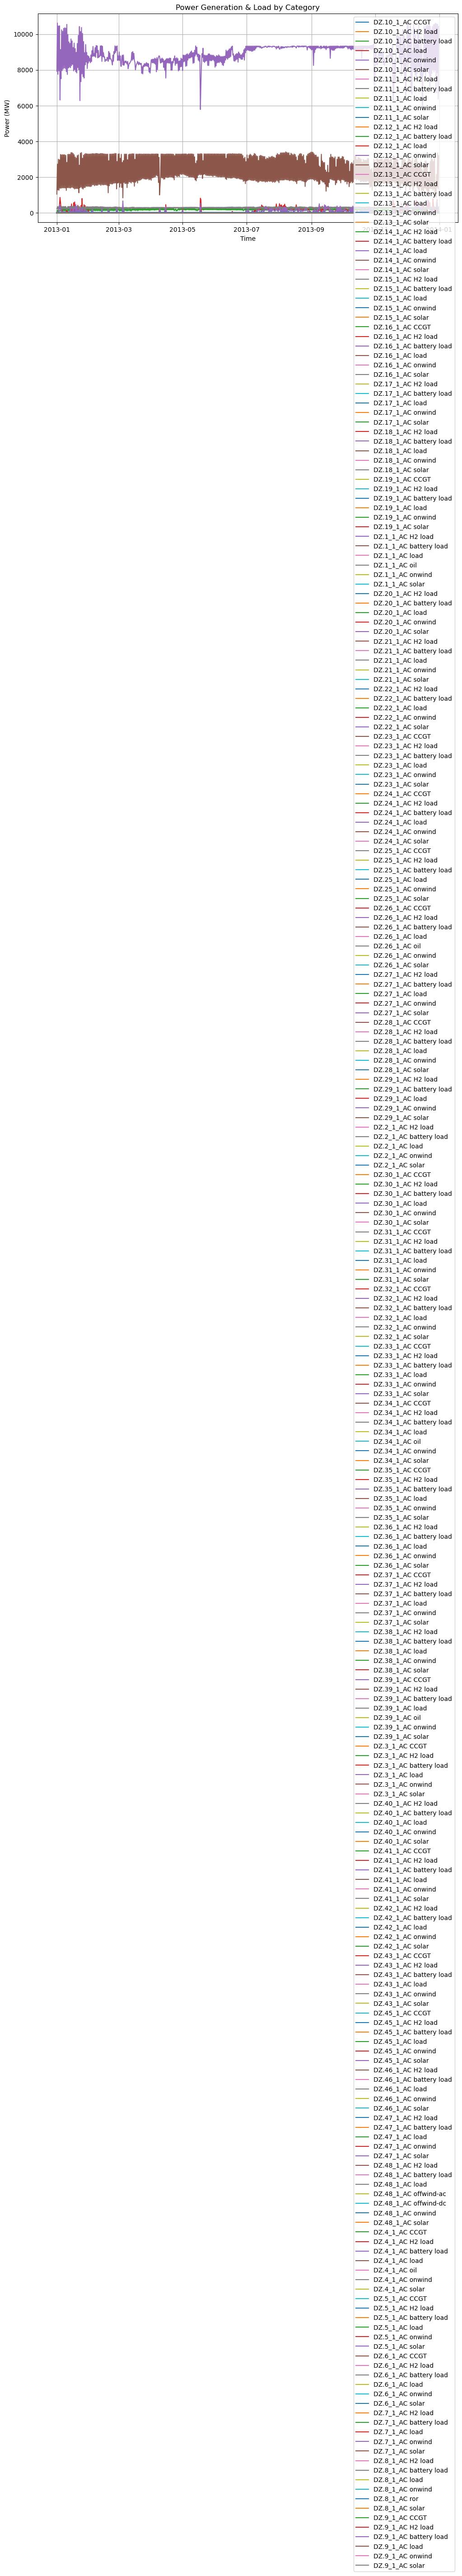

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt


# Step 1: Extract category names
categories = [re.sub(r'GH0 \d+ ', '', col) for col in df.columns]

# Step 2: Create a mapping from category name to a list of columns
category_columns = {}
for col, category in zip(df.columns, categories):
    if category not in category_columns:
        category_columns[category] = []
    category_columns[category].append(col)

# Step 3: Sum data for each category and create a new DataFrame
grouped_data = pd.DataFrame({category: df[cols].sum(axis=1) for category, cols in category_columns.items()})

# Step 4: Plot the grouped time series
plt.figure(figsize=(12, 6))
for category in grouped_data.columns:
    plt.plot(grouped_data.index, grouped_data[category], label=category, linestyle="-")

# Formatting the plot
plt.xlabel("Time")
plt.ylabel("Power (MW)")  # Adjust based on your data units
plt.title("Power Generation & Load by Category")
plt.legend()
plt.grid(True)
plt.show()


Total load in 2013: 104.01562756805447 TWh


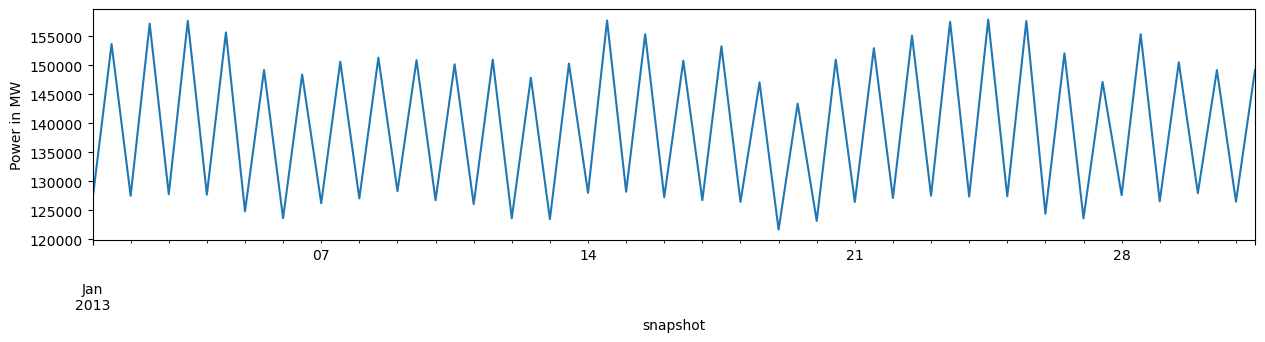

In [ ]:
loads = n.loads_t.p.multiply(n.snapshot_weightings.generators, axis=0)
fig, ax = plt.subplots(figsize=(15, 3))
loads.sum(axis=1).loc['2013-01-01':'2013-01-31'].plot(ax=ax)
ax.set_ylabel('Power in MW')
print('Total load in 2013: {} TWh'.format(n.loads_t.p.multiply(n.snapshot_weightings.generators, axis=0).sum(axis=1).sum() / 1000000))

In [ ]:
n.objective / 1e9 # billion europs p.a.
print("The total system cost is {:.0f} million euros per year".format(n.objective / 1e6))

The total system cost is 4340 million euros per year


## Line expansion

<AxesSubplot:xlabel='Line'>

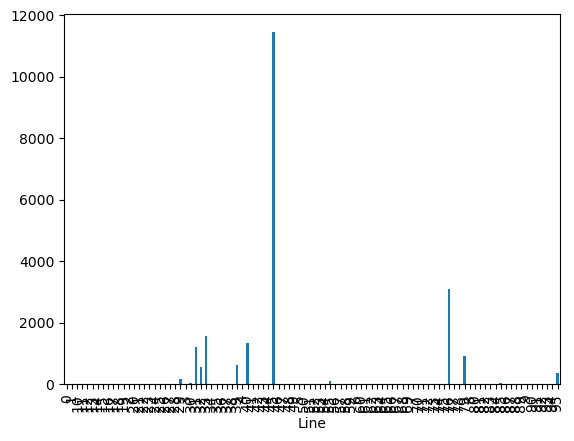

In [ ]:
(n.lines.s_nom_opt - n.lines.s_nom).plot.bar()

Text(0, 0.5, 'Capacity in GW')

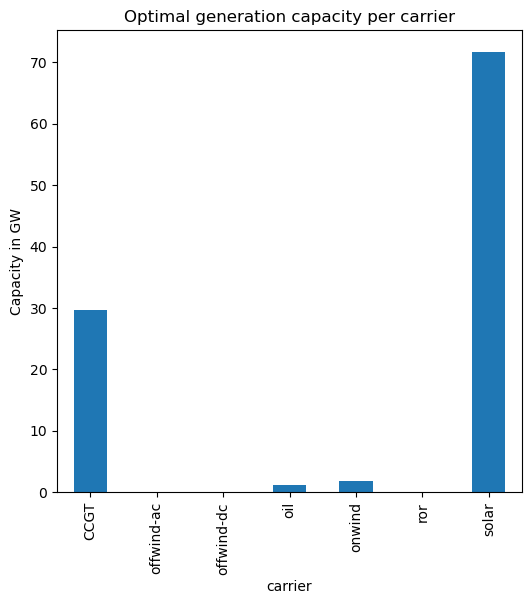

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
n.generators.groupby('carrier').p_nom_opt.sum().multiply(1e-3).plot.bar(ax = ax)
ax.set_title('Optimal generation capacity per carrier')
ax.set_ylabel('Capacity in GW')

In [ ]:
# n.generators.drop(n.generators[n.generators['carrier'] == 'load'], inplace=True)
n.generators = n.generators[n.generators['carrier'] != 'load']

In [ ]:
n.storage_units.groupby('carrier').p_nom_opt.sum() / 1e3 # GW

carrier
hydro    0.1
Name: p_nom_opt, dtype: float64

<AxesSubplot:xlabel='snapshot'>

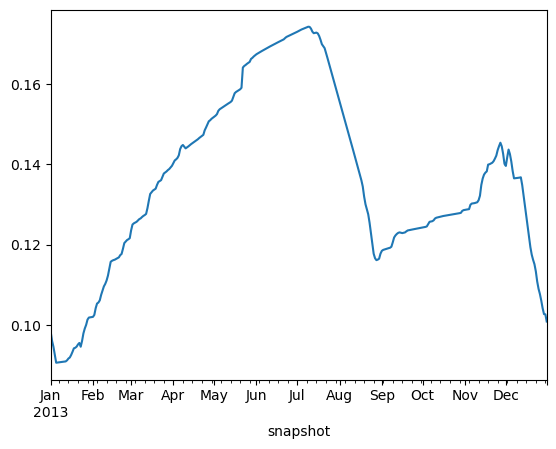

In [ ]:
(n.storage_units_t.state_of_charge.sum(axis=1).resample('D').mean() / 1e6).plot()

In [ ]:
n.storage_units_t.state_of_charge / 1e6

StorageUnit,DZ.8_1_AC hydro
snapshot,
2013-01-01 00:00:00,0.098892
2013-01-01 12:00:00,0.097579
2013-01-02 00:00:00,0.096294
2013-01-02 12:00:00,0.095729
2013-01-03 00:00:00,0.094613
...,...
2013-12-29 12:00:00,0.102924
2013-12-30 00:00:00,0.102510
2013-12-30 12:00:00,0.102766


In [ ]:
n.storage_units

,carrier,bus,p_nom,max_hours,p_min_pu,efficiency_dispatch,efficiency_store,cyclic_state_of_charge,control,marginal_cost,...,marginal_cost_quadratic,capital_cost,build_year,lifetime,state_of_charge_initial,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge_per_period,standing_loss,inflow
StorageUnit,,,,,,,,,,,,,,,,,,,,,
DZ.8_1_AC hydro,hydro,DZ.8_1_AC,100.0,2710.628395,0.0,0.9,0.0,True,,0.00992,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0


In [ ]:
n.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()

bus         carrier
DZ.10_1_AC  CCGT       1310.000000
            onwind        0.000426
            solar         0.161046
DZ.11_1_AC  onwind        0.000481
            solar         0.632076
                          ...     
DZ.8_1_AC   ror          21.377915
            solar         0.275766
DZ.9_1_AC   CCGT       2750.000000
            onwind        0.000956
            solar         4.234718
Name: p_nom_opt, Length: 127, dtype: float64

Text(0.5, 1.0, 'State of charge in TWh')

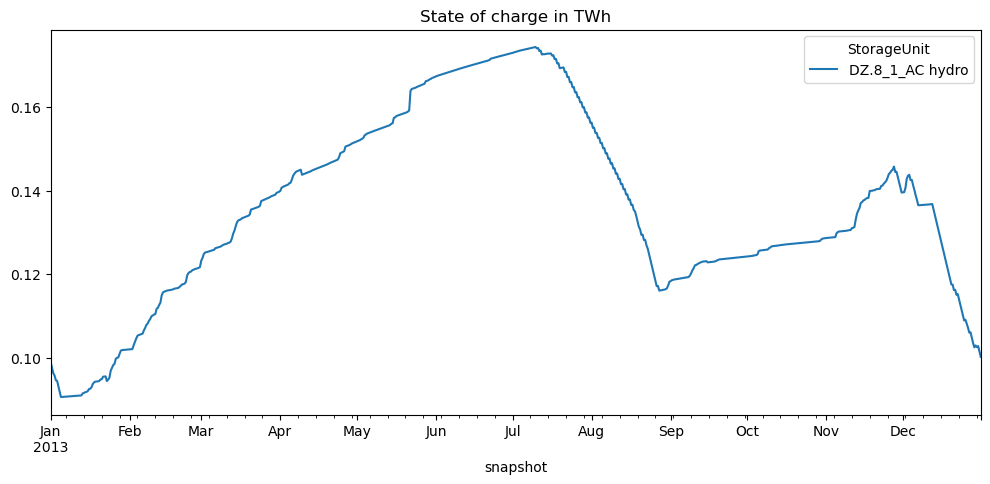

In [ ]:
fig, ax = plt.subplots(figsize=(12,5))
(n.storage_units_t.state_of_charge / 1e6).plot(ax = ax)
ax.set_title('State of charge in TWh')

In [ ]:
(n.storage_units_t.state_of_charge / 1e6)

StorageUnit,DZ.8_1_AC hydro
snapshot,
2013-01-01 00:00:00,0.098892
2013-01-01 12:00:00,0.097579
2013-01-02 00:00:00,0.096294
2013-01-02 12:00:00,0.095729
2013-01-03 00:00:00,0.094613
...,...
2013-12-29 12:00:00,0.102924
2013-12-30 00:00:00,0.102510
2013-12-30 12:00:00,0.102766


<AxesSubplot:xlabel='snapshot'>

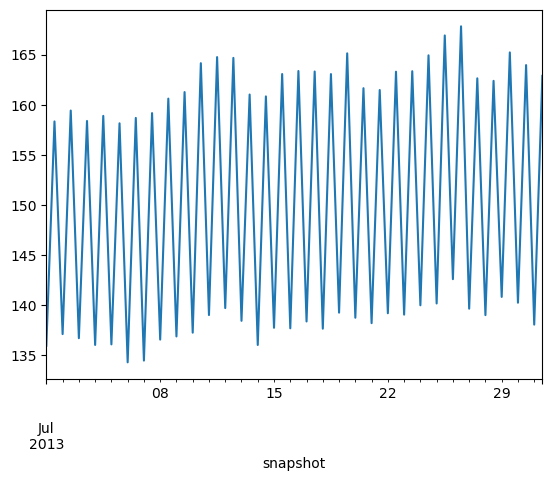

In [ ]:
(n.loads_t.p.sum(axis=1).multiply(n.snapshot_weightings.generators) / 1e3).loc['2013-07'].plot()

<AxesSubplot:xlabel='snapshot'>

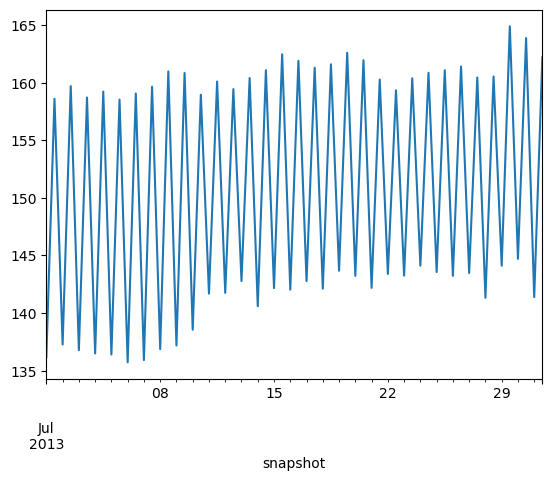

In [ ]:
(n.generators_t.p.sum(axis=1).multiply(n.snapshot_weightings.generators) / 1e3).loc['2013-07'].plot()

In [ ]:
gen_snap = n.generators_t.p.loc['2013-01-01 18:00:00']
gen_snap

KeyError: '2013-01-01 18:00:00'

<AxesSubplot:xlabel='snapshot'>

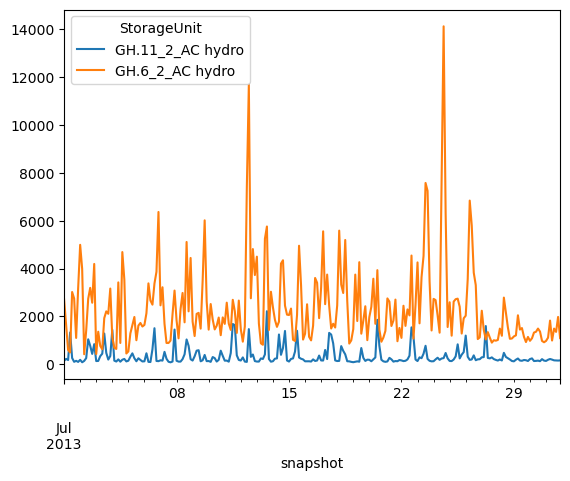

In [ ]:
n.storage_units_t.inflow.multiply(n.snapshot_weightings.generators, axis=0).loc['2013-07'].plot()

In [ ]:
n.statistics.capacity_factor(comps=["Generator", "StorageUnit"]).round(2)

component    carrier           
Generator    Offshore Wind (DC)    0.07
             Onshore Wind          0.11
             Run of River          1.00
             Solar                 0.13
StorageUnit  Reservoir & Dam       0.62
dtype: float64

In [ ]:
n.statistics.supply().loc["StorageUnit"] / 1e6 # from MWh to TWh

carrier
Reservoir & Dam    7.686043
dtype: float64

In [ ]:
n.statistics.dispatch(comps=["Generator", "StorageUnit"]).round(2) / 1e6

/tmp/ipykernel_18353/2211605357.py:1: DeprecatedWarning: dispatch is deprecated as of 0.28 and will be removed in 0.29. Use 'energy_balance' instead.
  n.statistics.dispatch(comps=["Generator", "StorageUnit"]).round(2) / 1e6


component    carrier           
Generator    Offshore Wind (DC)    3.000000e-08
             Onshore Wind          2.913540e-01
             Run of River          1.401528e+00
             Solar                 1.131490e+01
StorageUnit  Reservoir & Dam       7.686043e+00
dtype: float64

In [ ]:
(n.storage_units_t.inflow.sum(axis=0) / 1e6 * 3).sum()# TWh

9.862710000000002

In [ ]:
(n.storage_units_t.p.sum(axis=0) / 1e6 * 3).sum() # TWh

7.686043128490364

In [ ]:
n.storage_units_t.spill.sum(axis=0) / 1e6

StorageUnit
GH.11_2_AC hydro    0.000021
GH.6_2_AC hydro     0.440866
dtype: float64

In [ ]:
n.statistics.supply() / 1e6

component    carrier           
StorageUnit  Reservoir & Dam       7.686043e+00
Line         AC                    2.769693e+01
Link         H2 electrolysis       6.938188e-01
             H2 fuel cell          4.024149e-01
             battery charger       2.722818e+00
             battery discharger    2.450536e+00
Store        Battery Storage       2.722279e+00
             Hydrogen Storage      6.934614e-01
Generator    Offshore Wind (DC)    2.986375e-08
             Onshore Wind          2.913540e-01
             Run of River          1.401528e+00
             Solar                 1.131490e+01
dtype: float64

In [ ]:
hydro_storage = n.storage_units["p_nom"] * n.storage_units["max_hours"] / 1e6 # TWh
print(hydro_storage)

StorageUnit
GH.11_2_AC hydro    0.851124
GH.6_2_AC hydro     2.148876
dtype: float64


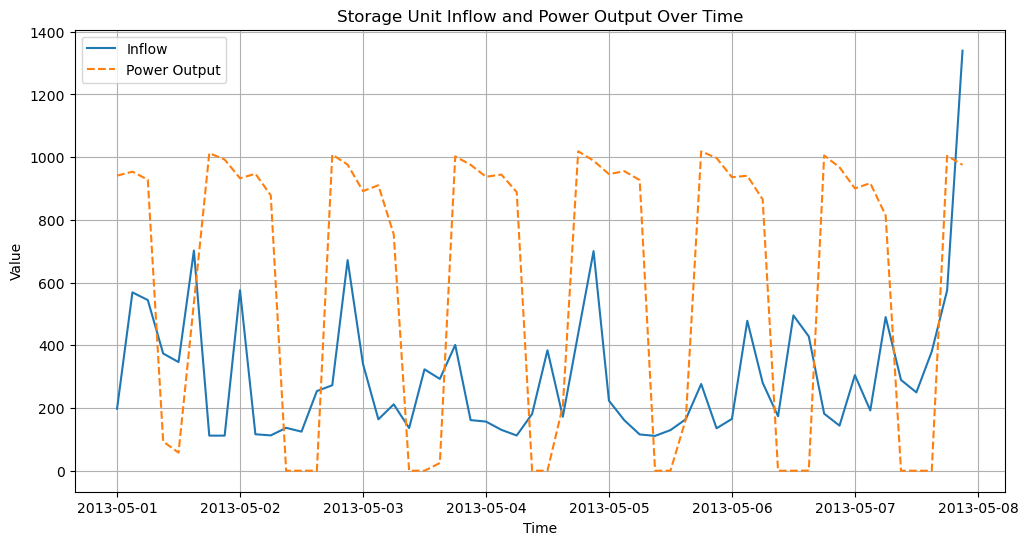

In [ ]:
n.storage_units_t.inflow
type(n.storage_units_t.p)

# Assuming n.storage_units_t.inflow and n.storage_units_t.p are Pandas DataFrames
fig, ax = plt.subplots(figsize=(12, 6))

# Plot inflow
ax.plot(n.storage_units_t.inflow.loc["2013-5-01":"2013-5-07", 'GH.6_2_AC hydro'], label='Inflow', linestyle='-', marker='')

# Plot p
ax.plot(n.storage_units_t.p.loc["2013-5-01":"2013-5-07", 'GH.6_2_AC hydro'], label='Power Output', linestyle='--', marker='')

ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.set_title('Storage Unit Inflow and Power Output Over Time')
ax.legend()
ax.grid(True)

plt.show()

<AxesSubplot:xlabel='snapshot'>

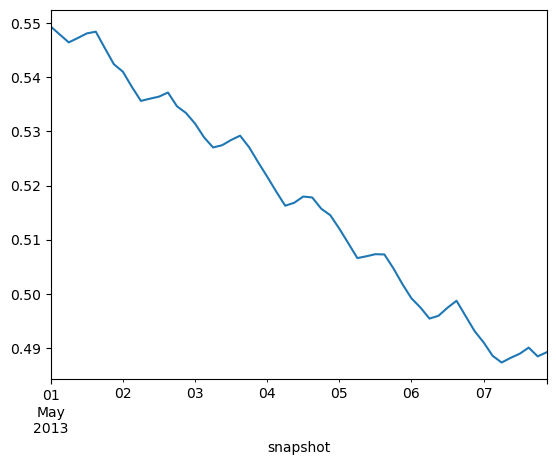

In [ ]:
(n.storage_units_t.state_of_charge.loc["2013-5-01":"2013-5-07", 'GH.6_2_AC hydro'] / 1e6).plot()

In [ ]:
n.storage_units.p_nom * n.storage_units.max_hours

StorageUnit
GH.11_2_AC hydro    8.511236e+05
GH.6_2_AC hydro     2.148876e+06
dtype: float64

In [ ]:
n.statistics()

Optimal Capacity  Installed Capacity  \
Generator   Combined-Cycle Gas       3952.154566         3952.154566   
            Offshore Wind (DC)          0.000049            0.000000   
            Oil                       509.484522          509.484522   
            Onshore Wind              314.181800            0.000000   
            Run of River              160.000000          160.000000   
            Solar                    9615.070230          168.954000   
Line        AC                      20392.073854        20278.920137   
Link        H2 electrolysis           782.267599            0.000000   
            H2 fuel cell              465.681202            0.000000   
            battery charger          1454.010084            0.000000   
            battery discharger       1615.566760            0.000000   
Load        -                           0.000000            0.000000   
StorageUnit Reservoir & Dam          1424.000000         1424.000000   
Store       Battery Storage          8603.302257            0.000000   
            Hydrogen Storage         7525.170733            0.000000   

                                      Supply    Withdrawal      Dispatch  \
Generator   Combined-Cycle Gas  0.000000e+00  0.000000e+00  0.000000e+00   
            Offshore Wind (DC)  2.986375e-02  0.000000e+00  2.986375e-02   
            Oil                 0.000000e+00  0.000000e+00  0.000000e+00   
            Onshore Wind        2.913540e+05  0.000000e+00  2.913540e+05   
            Run of River        1.401528e+06  0.000000e+00  1.401528e+06   
            Solar               1.131490e+07  0.000000e+00  1.131490e+07   
Line        AC                  2.769693e+07  2.769693e+07  0.000000e+00   
Link        H2 electrolysis     6.938188e+05  8.672736e+05 -1.734547e+05   
            H2 fuel cell        4.024149e+05  6.938188e+05 -2.914039e+05   
            battery charger     2.722818e+06  3.025354e+06 -3.025354e+05   
            battery discharger  2.450536e+06  2.722818e+06 -2.722818e+05   
Load        -                   0.000000e+00  1.965415e+07 -1.965415e+07   
StorageUnit Reservoir & Dam     7.686043e+06  0.000000e+00  7.686043e+06   
Store       Battery Storage     2.722279e+06  2.722279e+06 -1.818350e-10   
            Hydrogen Storage    6.934614e+05  6.934614e+05 -1.624372e-10   

                                Transmission  Capacity Factor   Curtailment  \
Generator   Combined-Cycle Gas      0.000000         0.000000  0.000000e+00   
            Offshore Wind (DC)      0.000000         0.070139  1.812026e-02   
            Oil                     0.000000         0.000000  0.000000e+00   
            Onshore Wind            0.000000         0.105861  5.173460e+04   
            Run of River            0.000000         0.999948  0.000000e+00   
            Solar                   0.000000         0.134337  1.514736e+06   
Line        AC                 -26507.690442         0.155048  0.000000e+00   
Link        H2 electrolysis         0.000000         0.126560  0.000000e+00   
            H2 fuel cell            0.000000         0.170080  0.000000e+00   
            battery charger         0.000000         0.237522  0.000000e+00   
            battery discharger      0.000000         0.192393  0.000000e+00   
Load        -                       0.000000              NaN  0.000000e+00   
StorageUnit Reservoir & Dam         0.000000         0.616153  0.000000e+00   
Store       Battery Storage         0.000000         0.437892  0.000000e+00   
            Hydrogen Storage        0.000000         0.504564  0.000000e+00   

                                Capital Expenditure  Operational Expenditure  \
Generator   Combined-Cycle Gas         3.338350e+08             0.000000e+00   
            Offshore Wind (DC)         1.223816e+01             7.200124e-04   
            Oil                        1.947992e+07             0.000000e+00   
            Onshore Wind               3.433868e+07             7.536445e+03 

In [ ]:
energy_balance_check = n.statistics.energy_balance().loc[:, :, "AC"]
energy_balance_check

component    carrier           
StorageUnit  Reservoir & Dam       7.686043e+06
Link         H2 electrolysis      -8.672736e+05
             battery charger      -3.025354e+06
             H2 fuel cell          4.024149e+05
             battery discharger    2.450536e+06
Load         -                    -1.965415e+07
Generator    Offshore Wind (DC)    2.986375e-02
             Onshore Wind          2.913540e+05
             Run of River          1.401528e+06
             Solar                 1.131490e+07
dtype: float64

In [ ]:
n.statistics.energy_balance()

component    carrier             bus_carrier
StorageUnit  Reservoir & Dam     AC             7.686043e+06
Link         H2 electrolysis     AC            -8.672736e+05
             H2 fuel cell        H2            -6.938188e+05
             battery charger     AC            -3.025354e+06
             battery discharger  battery       -2.722818e+06
             H2 electrolysis     H2             6.938188e+05
             H2 fuel cell        AC             4.024149e+05
             battery charger     battery        2.722818e+06
             battery discharger  AC             2.450536e+06
Store        Battery Storage     battery       -1.818350e-10
             Hydrogen Storage    H2            -1.624372e-10
Load         -                   AC            -1.965415e+07
Generator    Offshore Wind (DC)  AC             2.986375e-02
             Onshore Wind        AC             2.913540e+05
             Run of River        AC             1.401528e+06
             Solar               AC     

In [ ]:
energy_balance = n.statistics.energy_balance().loc[:, :, "AC"].groupby("carrier").sum().div(1e6).to_frame().T
print(energy_balance)

carrier          -  H2 electrolysis  H2 fuel cell  Offshore Wind (DC)  \
0       -19.654152        -0.867274      0.402415        2.986375e-08   

carrier  Onshore Wind  Reservoir & Dam  Run of River      Solar  \
0            0.291354         7.686043      1.401528  11.314903   

carrier  battery charger  battery discharger  
0              -3.025354            2.450536  


<AxesSubplot:xlabel='component,carrier'>

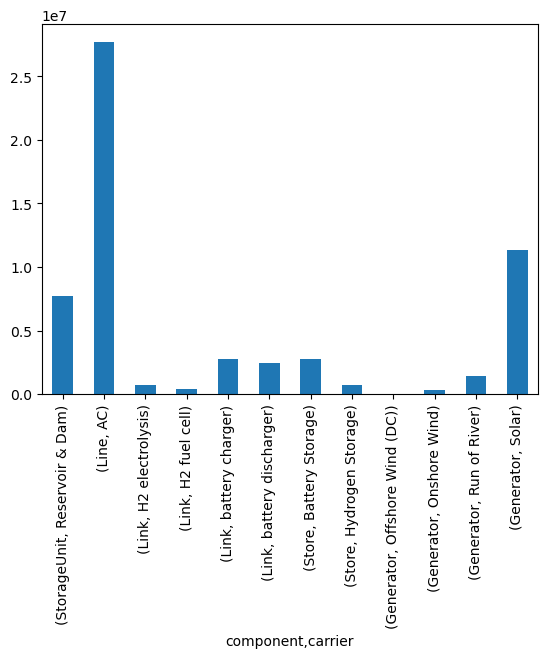

In [ ]:
n.statistics.supply().plot.bar()

/tmp/ipykernel_18353/968957247.py:1: DeprecatedWarning: dispatch is deprecated as of 0.28 and will be removed in 0.29. Use 'energy_balance' instead.
  (n.statistics.dispatch() / 1e6).plot.bar()


<AxesSubplot:xlabel='component,carrier'>

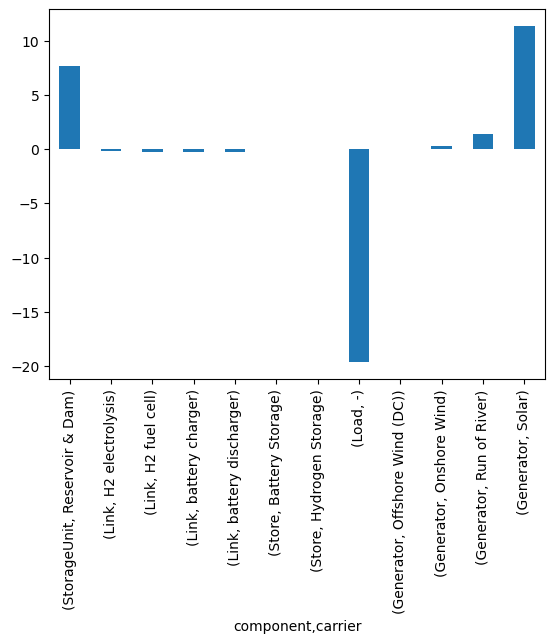

In [ ]:
(n.statistics.dispatch() / 1e6).plot.bar()